In [1]:
install.packages("table1")

Installing package into ‘/home/jupyter/.R/library’
(as ‘lib’ is unspecified)



In [2]:
library(bigrquery)
library(knitr)
library(tidyverse)
library(ggplot2)
library("table1")
library("IRdisplay")
library(grid)
library(gridExtra)
bq_auth()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘table1’


The following objects are masked from ‘package:base’:

    units, units<-



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [3]:
data <-bq_dataset_query(query="
SELECT *

 FROM `yhcr-prd-phm-bia-core.CB_1935_AK.src_bmbc_AlevelIMD`"
                       ,x="yhcr-prd-phm-bia-core.CB_1935_AK")

AlevelIMD <- bq_table_download(data) 

In [4]:
data1 <-bq_dataset_query(query="
select round(avg(count1),5)

from(

SELECT person_id,count(person_id) count1

 FROM `yhcr-prd-phm-bia-core.CB_1935_AK.src_bmbc_AlevelIMD`

 group by person_id)base"
                       ,x="yhcr-prd-phm-bia-core.CB_1935_AK")

AlevelIMDavg <- bq_table_download(data1) 

In [5]:
display_jupyter <- function(x) {
  css <- system.file("table1_defaults_1.0/table1_defaults.css", package="table1")
  css <- paste(readLines(css), collapse="\n")
  x <- htmltools::tagList(htmltools::tags$style(css), htmltools::tags$div(class="Rtable1", x))
  IRdisplay::display_html(as.character(x))
}

In [6]:
label(AlevelIMD$AcademicYear)      <- "Academic Year"

label(AlevelIMD$FSMEligible)      <- "Eligible for Free School Meals"
label(AlevelIMD$ethnic_group)      <- "Ethnic Group"
label(AlevelIMD$Gender)      <- "Gender"
label(AlevelIMD$IMD)      <- "Average IMD"

In [7]:
x <-table1(~ AlevelIMD$AcademicYear + AlevelIMD$FSMEligible+ AlevelIMD$Gender + AlevelIMD$ethnic_group+ AlevelIMD$IMD|AlevelIMD$ALevelOutcome,data=AlevelIMD
          ,justify=c("left", "left", rep("center", 5)),format_number = TRUE
          ,caption = "COSEY1: Development & Education -1.5 educational attainment.\t Number of students achieving A-Levels A*-B "
    
         )

In [8]:
display_jupyter(x)

,1. 3 Or More Alevels at A*-B(N=2838),2. >3 ALevels A* - B(N=5149),3. 0 ALevels(N=37455),Overall(N=45442)
Academic Year,,,,
2015/2016,711 (25.1%),1367 (26.5%),4380 (11.7%),6458 (14.2%)
2016/2017,736 (25.9%),1303 (25.3%),7775 (20.8%),9814 (21.6%)
2017/2018,696 (24.5%),1215 (23.6%),7700 (20.6%),9611 (21.2%)
2018/2019,695 (24.5%),1264 (24.5%),17600 (47.0%),19559 (43.0%)
Eligible for Free School Meals,,,,
false,2023 (71.3%),3634 (70.6%),10500 (28.0%),16157 (35.6%)
No Data,701 (24.7%),1154 (22.4%),25361 (67.7%),27216 (59.9%)
true,114 (4.0%),361 (7.0%),1594 (4.3%),2069 (4.6%)
Gender,,,,


In [12]:
AlevelIMD

person_id,ethnic_group,Gender,ALevelOutcome,AcademicYear,FSMEligible,IMD
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
12783500,White,Male,3. 0 ALevels,2017/2018,No Data,5
13757633,White,Female,3. 0 ALevels,2018/2019,false,4
13320648,White,Female,3. 0 ALevels,2017/2018,No Data,4
12505961,White,Male,3. 0 ALevels,2018/2019,No Data,No Data
10458816,White,Male,3. 0 ALevels,2018/2019,false,No Data
12779019,White,Female,3. 0 ALevels,2018/2019,No Data,6
390675,White,Male,3. 0 ALevels,2018/2019,No Data,No Data
557542,White,Male,3. 0 ALevels,2018/2019,No Data,6
13565733,White,Female,3. 0 ALevels,2018/2019,false,4


In [28]:
OverallTrend1 <- AlevelIMD %>% select(1,4,5)
#OverallTrend <- unique(filter(OverallTrend,ALevelOutcome == "1. 3 Or More Alevels at A*-B"))

In [29]:
OverallTrend1

person_id,ALevelOutcome,AcademicYear
<int>,<chr>,<chr>
12783500,3. 0 ALevels,2017/2018
13757633,3. 0 ALevels,2018/2019
13320648,3. 0 ALevels,2017/2018
12505961,3. 0 ALevels,2018/2019
10458816,3. 0 ALevels,2018/2019
12779019,3. 0 ALevels,2018/2019
390675,3. 0 ALevels,2018/2019
557542,3. 0 ALevels,2018/2019
13565733,3. 0 ALevels,2018/2019


In [47]:
Alevel_percentage <- OverallTrend %>%
  group_by(AcademicYear,ALevelOutcome) #%>%
  #summarise(percentage = (count(personid) / count(sum(person_id))* 100))
Alevel_percentage1 %>% count(person_id)



In [77]:
ALevel1<- Alevel_percentage %>% count(ALevelOutcome,AcademicYear)

In [78]:
x<- group_by(ALevel1, AcademicYear) %>% mutate(percent = (n/sum(n))*100)

In [80]:
x <-unique(filter(x,ALevelOutcome == "1. 3 Or More Alevels at A*-B"))

In [81]:
x

AcademicYear,ALevelOutcome,n,percent
<chr>,<chr>,<int>,<dbl>
2015/2016,1. 3 Or More Alevels at A*-B,711,11.009600
2016/2017,1. 3 Or More Alevels at A*-B,736,7.499491
2017/2018,1. 3 Or More Alevels at A*-B,696,7.241702
2018/2019,1. 3 Or More Alevels at A*-B,695,3.553351


In [87]:
#install.packages('scales')
#library(scales) # For the percent_format() function

#scale_y_continuous(labels = percent_format(), limits=c(0,1))

Installing package into ‘/home/jupyter/.R/library’
(as ‘lib’ is unspecified)



ERROR: Error in value[[3L]](cond): Package ‘scales’ version 1.2.1 cannot be unloaded:
 Error in unloadNamespace(package) : namespace ‘scales’ is imported by ‘ggplot2’ so cannot be unloaded



`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


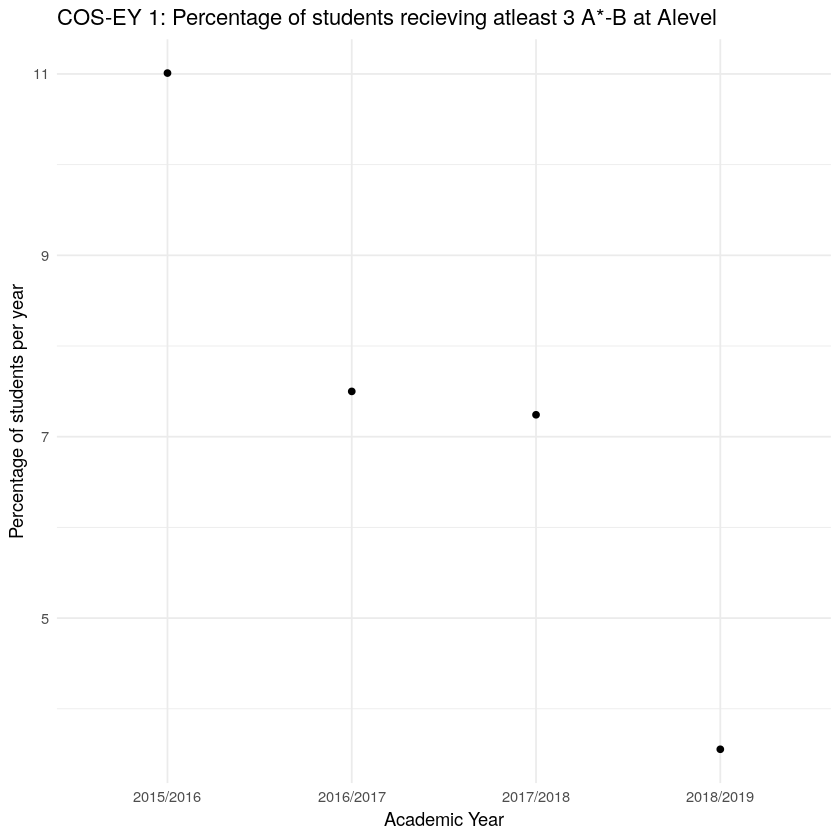

In [91]:

#x$AcademicYear <- factor(x$AcademicYear), levels = as.character(2012:2023))

ggplot(x , aes(x = AcademicYear, y = percent,group = )) +
#scale_y_continuous( limits=c(0,1))+
  geom_line() +
  geom_point() +
  labs(title = "COS-EY 1: Percentage of students recieving atleast 3 A*-B at Alevel",
       x = "Academic Year",
       y = "Percentage of students per year") +
  theme_minimal()